=== Data-Driven Persona Development with PCA ===
This notebook demonstrates how to extract meaningful user personas from behavioral data

STEP 1: Generating Synthetic User Behavioral Data
--------------------------------------------------
Generated data for 1000 users with 10 behavioral features

Dataset shape: (1000, 11)

First few rows:
   user_id  time_spent_browsing  session_frequency  avg_session_duration  \
0        1             6.630014                6.0             43.015657   
1        2             2.988929                2.0             13.908104   
2        3             2.764567                8.0             73.489303   
3        4             2.764605                9.0              3.225104   
4        5             9.299429               10.0             24.336954   

   content_interactions  content_creation  social_connections  \
0             28.432043               4.0          236.772165   
1             18.809786               4.0           19.021498   
2      

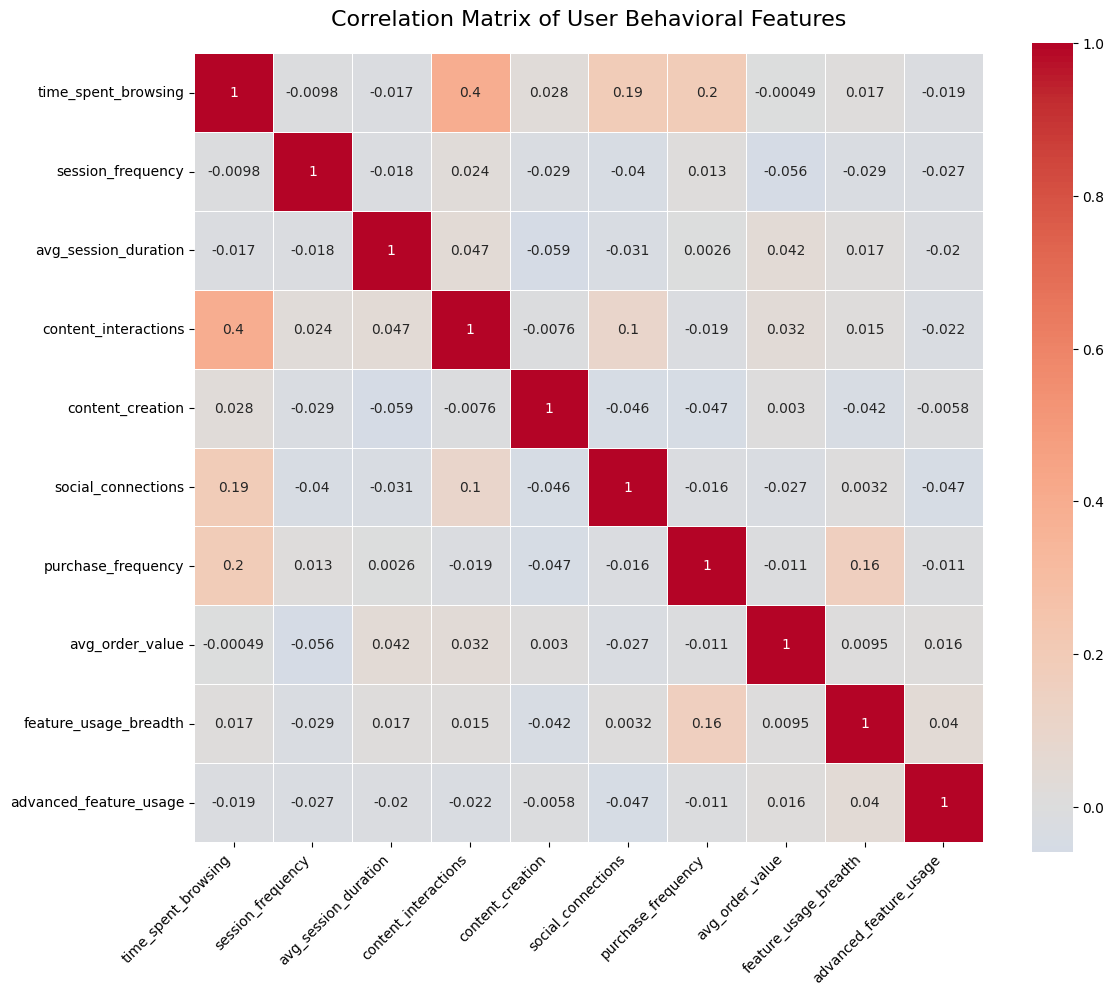

Correlation Analysis:
- Strong correlations indicate features that tend to vary together
- This helps us understand user behavior patterns before applying PCA


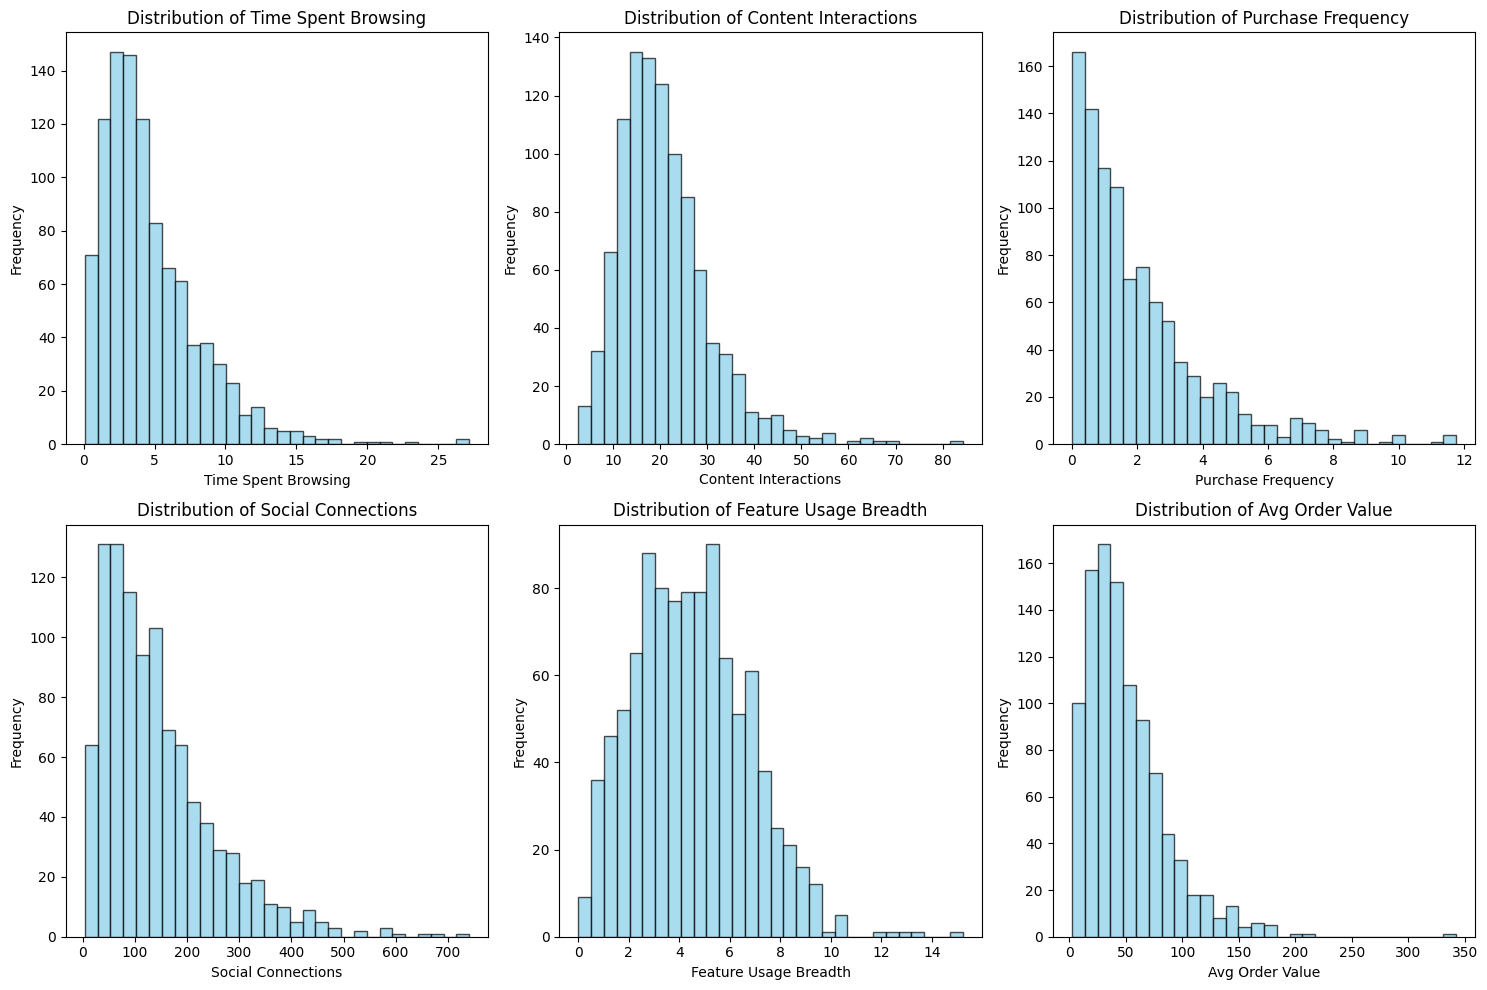



STEP 3: Data Preprocessing for PCA
--------------------------------------------------
Original feature ranges:
time_spent_browsing: 0.09 to 27.17
session_frequency: 1.00 to 16.00
avg_session_duration: 0.15 to 148.36
content_interactions: 2.61 to 84.28
content_creation: 0.00 to 10.00
social_connections: 4.00 to 741.01
purchase_frequency: 0.00 to 11.76
avg_order_value: 2.38 to 342.37
feature_usage_breadth: 0.01 to 15.21
advanced_feature_usage: 0.00 to 4.11

After standardization (mean=0, std=1):
All features now have mean ≈ 0 and standard deviation ≈ 1
This ensures no single feature dominates the PCA due to scale differences


STEP 4: Applying Principal Component Analysis
--------------------------------------------------
Total number of components: 10

Explained variance by each component:
PC1: 0.152 (15.2%)
PC2: 0.118 (11.8%)
PC3: 0.109 (10.9%)
PC4: 0.106 (10.6%)
PC5: 0.101 (10.1%)
PC6: 0.099 (9.9%)
PC7: 0.093 (9.3%)
PC8: 0.086 (8.6%)
PC9: 0.082 (8.2%)
PC10: 0.052 (5.2%)

Cumulative 

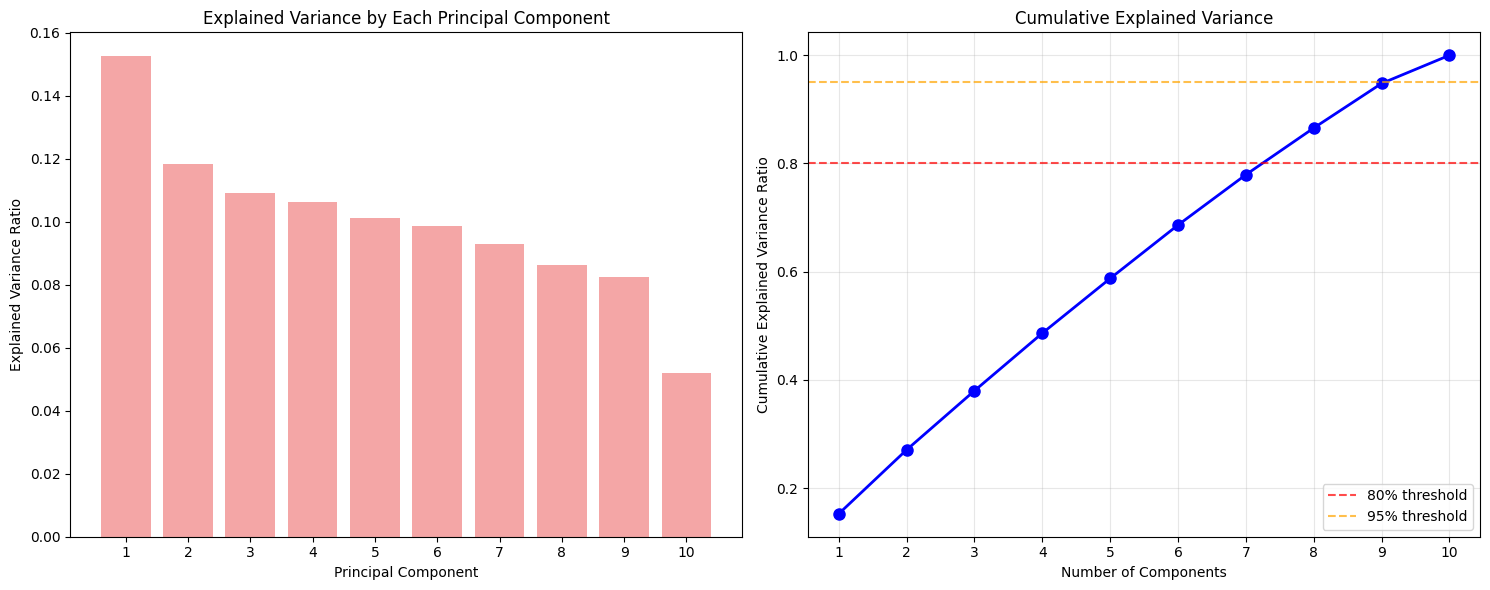


Components needed to explain 80% of variance: 8
Components needed to explain 95% of variance: 10

For persona development, we'll focus on the first few components as they capture
the most significant patterns in user behavior.


STEP 5: Analyzing Principal Components for Persona Insights
--------------------------------------------------
Component Loadings (First 5 Components):
These show how much each original feature contributes to each principal component
                          PC1    PC2    PC3    PC4    PC5
time_spent_browsing     0.670 -0.051 -0.022  0.112 -0.123
session_frequency      -0.009 -0.052 -0.510 -0.367 -0.524
avg_session_duration    0.023  0.142  0.445 -0.575 -0.155
content_interactions    0.579 -0.210  0.156 -0.082 -0.244
content_creation       -0.038 -0.289  0.015  0.590 -0.395
social_connections      0.356 -0.209 -0.064 -0.026  0.634
purchase_frequency      0.259  0.600 -0.234  0.100 -0.123
avg_order_value         0.013  0.054  0.649  0.038 -0.201
feature_usage_

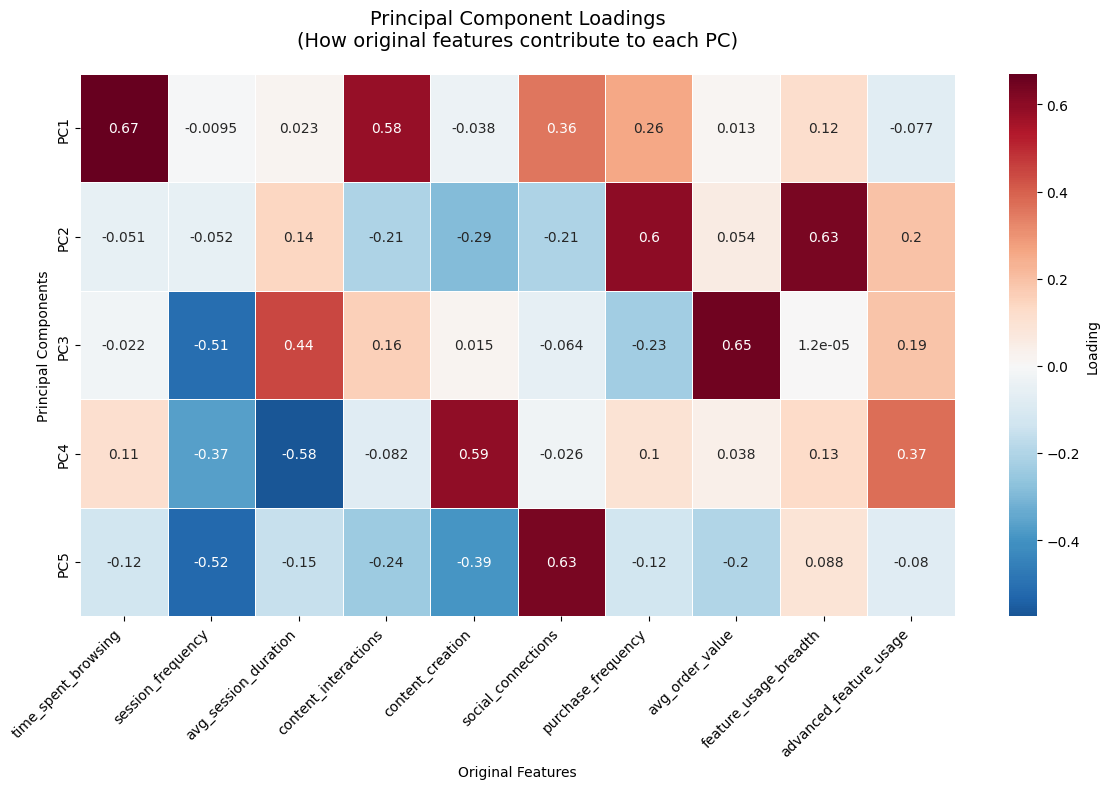


Component Interpretation:

PC1 (explains 15.2% of variance):
  High positive loadings: time_spent_browsing, content_interactions, social_connections
  High negative loadings: advanced_feature_usage, content_creation, session_frequency
  → Likely represents 'Overall Engagement Level'

PC2 (explains 11.8% of variance):
  High positive loadings: feature_usage_breadth, purchase_frequency, advanced_feature_usage
  High negative loadings: content_creation, content_interactions, social_connections
  → Likely represents 'Social vs. Transactional Behavior'

PC3 (explains 10.9% of variance):
  High positive loadings: avg_order_value, avg_session_duration, advanced_feature_usage
  High negative loadings: session_frequency, purchase_frequency, social_connections
  → Likely represents 'Content Creation vs. Consumption'

PC4 (explains 10.6% of variance):
  High positive loadings: content_creation, advanced_feature_usage, feature_usage_breadth
  High negative loadings: avg_session_duration, session_

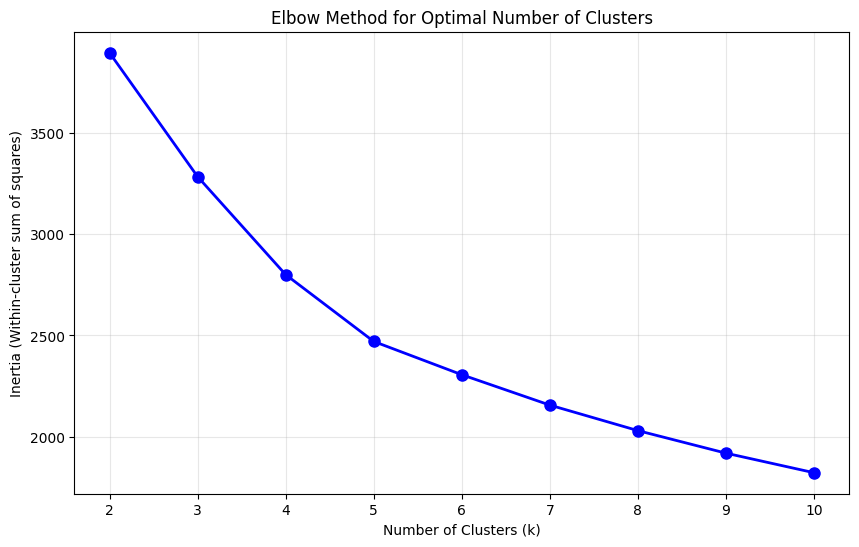

Using 5 clusters to create 5 distinct personas

Persona distribution:
Persona 0: 292 users (29.2%)
Persona 1: 166 users (16.6%)
Persona 2: 246 users (24.6%)
Persona 3: 164 users (16.4%)
Persona 4: 132 users (13.2%)


STEP 7: Visualizing Personas in PCA Space
--------------------------------------------------


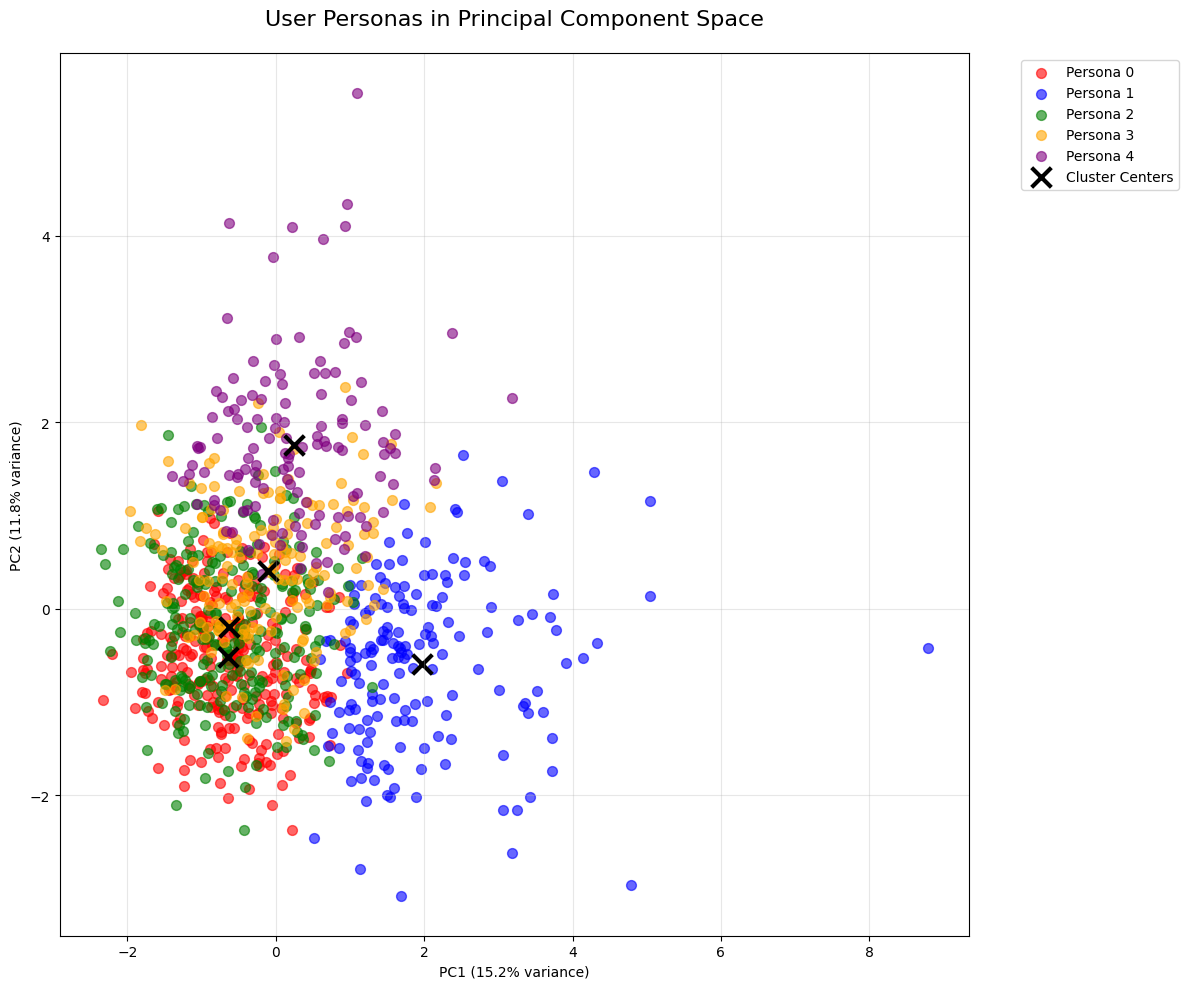



STEP 8: Detailed Persona Characterization
--------------------------------------------------
Average feature values by persona:
                 time_spent_browsing  session_frequency  avg_session_duration  \
persona_cluster                                                                 
0                               3.31               9.29                 21.19   
1                               9.61               7.90                 24.41   
2                               3.52               6.16                 21.54   
3                               3.95               7.90                 58.90   
4                               4.69               8.11                 24.42   

                 content_interactions  content_creation  social_connections  \
persona_cluster                                                               
0                               17.32              3.03              130.44   
1                               32.82              3.33          

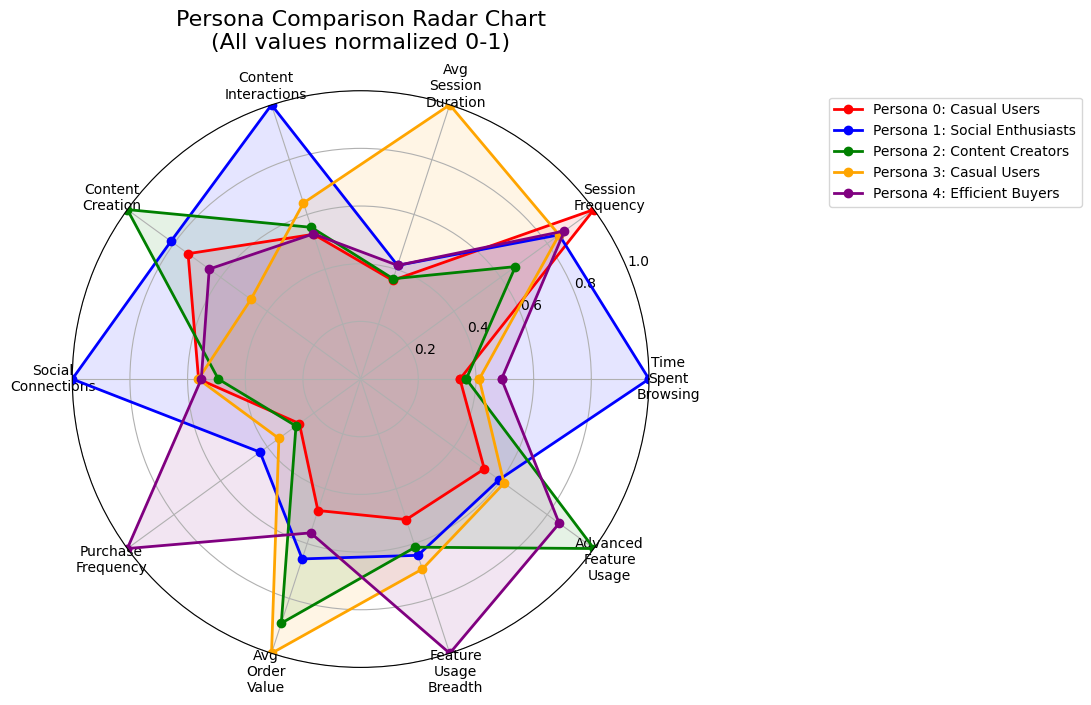

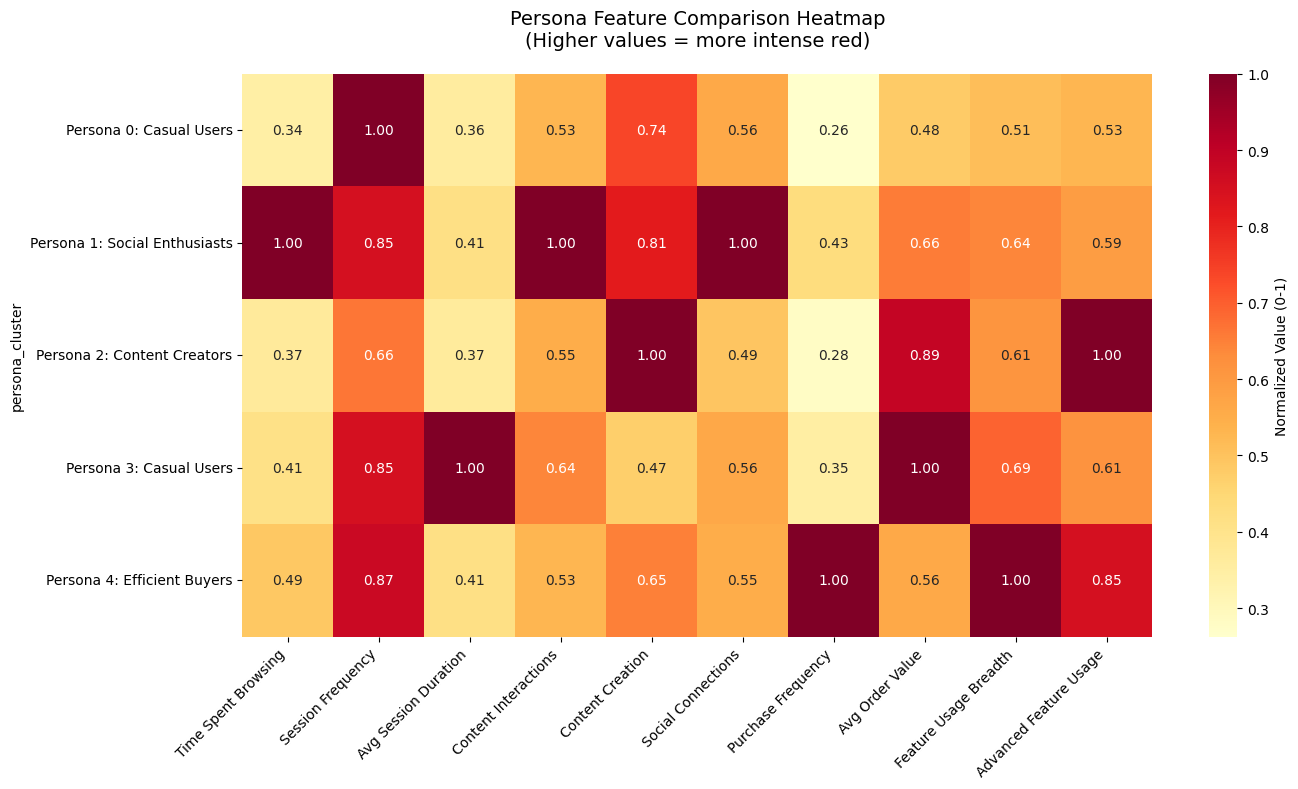



STEP 10: Business Insights and Recommendations
--------------------------------------------------
KEY INSIGHTS FROM PCA-BASED PERSONA ANALYSIS:

1. DATA DIMENSIONALITY REDUCTION:
   • Original 10 features reduced to 8 components
   • 8 components explain 86.6% of user behavior variance
   • This simplification enables clearer persona understanding

2. PERSONA DIVERSITY:
   • Identified 5 distinct user personas
   • Largest persona: 292 users (29.2%)
   • Smallest persona: 132 users (13.2%)
   • Good distribution suggests meaningful segmentation

3. PRINCIPAL COMPONENT INSIGHTS:
   • PC1: 15.2% of variance - represents core behavioral dimension
   • PC2: 11.8% of variance - represents core behavioral dimension
   • PC3: 10.9% of variance - represents core behavioral dimension

4. PERSONA-SPECIFIC RECOMMENDATIONS:

   Casual Users (292 users):
   • Users with moderate engagement across all features
   • Strategy: Engagement campaigns, onboarding improvements

   Social Enthusiasts (166

In [2]:
# Data-Driven Persona Development using Principal Component Analysis (PCA)
# This notebook demonstrates how to use PCA to identify user personas from behavioral data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("=== Data-Driven Persona Development with PCA ===")
print("This notebook demonstrates how to extract meaningful user personas from behavioral data")
print()

# =====================================
# STEP 1: GENERATE SYNTHETIC USER DATA
# =====================================

print("STEP 1: Generating Synthetic User Behavioral Data")
print("-" * 50)

# Define the number of users
n_users = 1000

# Generate synthetic behavioral features that might be collected from users
# These represent different aspects of user behavior on a platform

# Time-based features
time_spent_browsing = np.random.gamma(2, 2, n_users)  # Average time spent browsing (hours/week)
session_frequency = np.random.poisson(8, n_users).astype(float)    # Number of sessions per week
avg_session_duration = np.random.gamma(1.5, 20, n_users)  # Average session duration (minutes)

# Engagement features
content_interactions = np.random.poisson(15, n_users).astype(float)  # Likes, comments, shares per week
content_creation = np.random.poisson(3, n_users).astype(float)       # Posts/content created per week
social_connections = np.random.gamma(2, 50, n_users)   # Number of friends/followers

# Purchase/conversion features
purchase_frequency = np.random.gamma(1, 2, n_users)    # Purchases per month
avg_order_value = np.random.gamma(2, 25, n_users)      # Average order value ($)

# Feature exploration behavior
feature_usage_breadth = np.random.beta(2, 3, n_users) * 10  # Number of different features used
advanced_feature_usage = np.random.beta(1, 4, n_users) * 5  # Usage of advanced features

# Add some correlations to make the data more realistic
# Heavy users tend to have more social connections and higher engagement
heavy_user_multiplier = 1 + (time_spent_browsing / 10)
social_connections *= heavy_user_multiplier * np.random.normal(1, 0.2, n_users)
content_interactions *= heavy_user_multiplier * np.random.normal(1, 0.3, n_users)

# Purchasers tend to browse more and use more features
purchase_indicator = purchase_frequency > np.percentile(purchase_frequency, 70)
time_spent_browsing[purchase_indicator] *= np.random.normal(1.5, 0.3, sum(purchase_indicator))
feature_usage_breadth[purchase_indicator] *= np.random.normal(1.3, 0.2, sum(purchase_indicator))

# Create the dataset
user_data = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'time_spent_browsing': time_spent_browsing,
    'session_frequency': session_frequency,
    'avg_session_duration': avg_session_duration,
    'content_interactions': content_interactions,
    'content_creation': content_creation,
    'social_connections': social_connections,
    'purchase_frequency': purchase_frequency,
    'avg_order_value': avg_order_value,
    'feature_usage_breadth': feature_usage_breadth,
    'advanced_feature_usage': advanced_feature_usage
})

print(f"Generated data for {n_users} users with {len(user_data.columns)-1} behavioral features")
print("\nDataset shape:", user_data.shape)
print("\nFirst few rows:")
print(user_data.head())

print("\nBasic statistics:")
print(user_data.describe().round(2))

# =====================================
# STEP 2: DATA EXPLORATION & VISUALIZATION
# =====================================

print("\n\nSTEP 2: Data Exploration and Visualization")
print("-" * 50)

# Create correlation matrix to understand relationships between features
feature_columns = user_data.columns[1:]  # Exclude user_id
correlation_matrix = user_data[feature_columns].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of User Behavioral Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Correlation Analysis:")
print("- Strong correlations indicate features that tend to vary together")
print("- This helps us understand user behavior patterns before applying PCA")

# Plot distribution of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = ['time_spent_browsing', 'content_interactions', 'purchase_frequency',
                'social_connections', 'feature_usage_breadth', 'avg_order_value']

for i, feature in enumerate(key_features):
    row, col = i // 3, i % 3
    axes[row, col].hist(user_data[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[row, col].set_xlabel(feature.replace("_", " ").title())
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# =====================================
# STEP 3: DATA PREPROCESSING FOR PCA
# =====================================

print("\n\nSTEP 3: Data Preprocessing for PCA")
print("-" * 50)

# Extract features for PCA (exclude user_id)
features_for_pca = user_data[feature_columns].copy()

print("Original feature ranges:")
for col in features_for_pca.columns:
    print(f"{col}: {features_for_pca[col].min():.2f} to {features_for_pca[col].max():.2f}")

# Standardize the features
# PCA is sensitive to feature scales, so we need to standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_pca)
features_scaled_df = pd.DataFrame(features_scaled, columns=feature_columns)

print("\nAfter standardization (mean=0, std=1):")
print("All features now have mean ≈ 0 and standard deviation ≈ 1")
print("This ensures no single feature dominates the PCA due to scale differences")

# =====================================
# STEP 4: APPLY PCA
# =====================================

print("\n\nSTEP 4: Applying Principal Component Analysis")
print("-" * 50)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(features_scaled)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"Total number of components: {len(explained_variance_ratio)}")
print("\nExplained variance by each component:")
for i, variance in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {variance:.3f} ({variance*100:.1f}%)")

print(f"\nCumulative explained variance:")
for i, cum_variance in enumerate(cumulative_variance_ratio):
    print(f"First {i+1} components: {cum_variance:.3f} ({cum_variance*100:.1f}%)")

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        alpha=0.7, color='lightcoral')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance by Each Principal Component')
ax1.set_xticks(range(1, len(explained_variance_ratio) + 1))

# Cumulative explained variance
ax2.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio,
         'bo-', linewidth=2, markersize=8)
ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(cumulative_variance_ratio) + 1))

plt.tight_layout()
plt.show()

# Determine number of components for persona development
# Common thresholds: 80% or 95% of variance explained
components_80 = np.argmax(cumulative_variance_ratio >= 0.8) + 1
components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f"\nComponents needed to explain 80% of variance: {components_80}")
print(f"Components needed to explain 95% of variance: {components_95}")
print("\nFor persona development, we'll focus on the first few components as they capture")
print("the most significant patterns in user behavior.")

# =====================================
# STEP 5: ANALYZE PRINCIPAL COMPONENTS
# =====================================

print("\n\nSTEP 5: Analyzing Principal Components for Persona Insights")
print("-" * 50)

# Get the component loadings (how much each original feature contributes to each PC)
components_df = pd.DataFrame(
    pca.components_[:5].T,  # First 5 components
    columns=[f'PC{i+1}' for i in range(5)],
    index=feature_columns
)

print("Component Loadings (First 5 Components):")
print("These show how much each original feature contributes to each principal component")
print(components_df.round(3))

# Visualize component loadings
plt.figure(figsize=(12, 8))
sns.heatmap(components_df.T, annot=True, cmap='RdBu_r', center=0,
            square=False, linewidths=0.5, cbar_kws={'label': 'Loading'})
plt.title('Principal Component Loadings\n(How original features contribute to each PC)',
          fontsize=14, pad=20)
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Interpret the first few components
print("\nComponent Interpretation:")
print("=" * 30)

for i in range(min(4, len(components_df.columns))):
    pc_name = f'PC{i+1}'
    pc_loadings = components_df[pc_name]

    # Find features with highest positive and negative loadings
    top_positive = pc_loadings.nlargest(3)
    top_negative = pc_loadings.nsmallest(3)

    print(f"\n{pc_name} (explains {explained_variance_ratio[i]*100:.1f}% of variance):")
    print(f"  High positive loadings: {', '.join(top_positive.index.tolist())}")
    print(f"  High negative loadings: {', '.join(top_negative.index.tolist())}")

    # Provide interpretation
    if i == 0:
        print("  → Likely represents 'Overall Engagement Level'")
    elif i == 1:
        print("  → Likely represents 'Social vs. Transactional Behavior'")
    elif i == 2:
        print("  → Likely represents 'Content Creation vs. Consumption'")
    elif i == 3:
        print("  → Likely represents 'Feature Exploration vs. Basic Usage'")

# =====================================
# STEP 6: CREATE USER PERSONAS USING CLUSTERING
# =====================================

print("\n\nSTEP 6: Creating User Personas through Clustering")
print("-" * 50)

# Use first few principal components for clustering
n_components_for_clustering = 4  # Use first 4 components
pca_features = pca_result[:, :n_components_for_clustering]

# Determine optimal number of clusters using elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

# Choose number of clusters (let's use 5 for diverse personas)
n_clusters = 5
print(f"Using {n_clusters} clusters to create {n_clusters} distinct personas")

# Apply K-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
user_clusters = kmeans.fit_predict(pca_features)

# Add cluster labels to original data
user_data['persona_cluster'] = user_clusters

print(f"\nPersona distribution:")
persona_counts = pd.Series(user_clusters).value_counts().sort_index()
for cluster_id, count in persona_counts.items():
    percentage = (count / len(user_data)) * 100
    print(f"Persona {cluster_id}: {count} users ({percentage:.1f}%)")

# =====================================
# STEP 7: VISUALIZE PERSONAS IN PCA SPACE
# =====================================

print("\n\nSTEP 7: Visualizing Personas in PCA Space")
print("-" * 50)

# Create 2D visualization using first two principal components
plt.figure(figsize=(12, 10))

# Color map for clusters
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

for cluster_id in range(n_clusters):
    cluster_mask = user_clusters == cluster_id
    plt.scatter(pca_result[cluster_mask, 0], pca_result[cluster_mask, 1],
                c=colors[cluster_id], label=f'Persona {cluster_id}',
                alpha=0.6, s=50)

# Add cluster centers
cluster_centers_pca = kmeans.cluster_centers_
plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1],
            c='black', marker='x', s=200, linewidths=3, label='Cluster Centers')

plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
plt.title('User Personas in Principal Component Space', fontsize=16, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================
# STEP 8: CHARACTERIZE EACH PERSONA
# =====================================

print("\n\nSTEP 8: Detailed Persona Characterization")
print("-" * 50)

# Calculate mean values for each feature by persona
persona_characteristics = user_data.groupby('persona_cluster')[feature_columns].mean()

print("Average feature values by persona:")
print(persona_characteristics.round(2))

# Create detailed persona profiles
persona_names = []
persona_descriptions = []

for cluster_id in range(n_clusters):
    cluster_data = persona_characteristics.loc[cluster_id]

    # Determine persona characteristics based on feature values
    # Compare to overall means
    overall_means = user_data[feature_columns].mean()

    high_features = []
    low_features = []

    for feature in feature_columns:
        if cluster_data[feature] > overall_means[feature] * 1.2:  # 20% above average
            high_features.append(feature.replace('_', ' '))
        elif cluster_data[feature] < overall_means[feature] * 0.8:  # 20% below average
            low_features.append(feature.replace('_', ' '))

    # Generate persona names and descriptions
    if cluster_data['time_spent_browsing'] > overall_means['time_spent_browsing'] * 1.3:
        if cluster_data['purchase_frequency'] > overall_means['purchase_frequency'] * 1.2:
            name = "Power Shoppers"
            description = "High-engagement users who spend significant time on the platform and make frequent purchases"
        elif cluster_data['content_interactions'] > overall_means['content_interactions'] * 1.2:
            name = "Social Enthusiasts"
            description = "Highly engaged users focused on social interactions and content engagement"
        else:
            name = "Heavy Browsers"
            description = "Users who spend lots of time browsing but have moderate engagement in other areas"
    elif cluster_data['purchase_frequency'] > overall_means['purchase_frequency'] * 1.2:
        name = "Efficient Buyers"
        description = "Users who make purchases efficiently without extensive browsing"
    elif cluster_data['content_creation'] > overall_means['content_creation'] * 1.2:
        name = "Content Creators"
        description = "Users focused on creating and sharing content"
    else:
        name = "Casual Users"
        description = "Users with moderate engagement across all features"

    persona_names.append(name)
    persona_descriptions.append(description)

    print(f"\n{'='*60}")
    print(f"PERSONA {cluster_id}: {name}")
    print(f"{'='*60}")
    print(f"Size: {persona_counts[cluster_id]} users ({(persona_counts[cluster_id]/len(user_data)*100):.1f}%)")
    print(f"Description: {description}")
    print(f"\nKey Characteristics:")
    if high_features:
        print(f"  • High: {', '.join(high_features[:3])}")  # Show top 3
    if low_features:
        print(f"  • Low: {', '.join(low_features[:3])}")   # Show top 3

    print(f"\nDetailed Metrics:")
    for feature in feature_columns:
        value = cluster_data[feature]
        overall_avg = overall_means[feature]
        percentage_diff = ((value - overall_avg) / overall_avg) * 100
        print(f"  • {feature.replace('_', ' ').title()}: {value:.2f} ({percentage_diff:+.0f}% vs avg)")

# =====================================
# STEP 9: PERSONA COMPARISON VISUALIZATION
# =====================================

print("\n\nSTEP 9: Visual Persona Comparison")
print("-" * 50)

# Create radar chart for persona comparison
def create_radar_chart(personas_data, persona_names):
    # Normalize data for radar chart (0-1 scale)
    normalized_data = personas_data.div(personas_data.max(axis=0), axis=1)

    # Number of features
    num_features = len(feature_columns)
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

    for i, (cluster_id, persona_name) in enumerate(zip(range(n_clusters), persona_names)):
        values = normalized_data.loc[cluster_id].tolist()
        values += values[:1]  # Complete the circle

        ax.plot(angles, values, 'o-', linewidth=2, label=f'Persona {cluster_id}: {persona_name}',
                color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    # Add feature labels
    feature_labels = [f.replace('_', '\n').title() for f in feature_columns]
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Persona Comparison Radar Chart\n(All values normalized 0-1)',
                 fontsize=16, pad=30)
    ax.legend(bbox_to_anchor=(1.3, 1.0), loc='upper left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

create_radar_chart(persona_characteristics, persona_names)

# Create heatmap comparison
plt.figure(figsize=(14, 8))
# Normalize for better visualization
normalized_personas = persona_characteristics.div(persona_characteristics.max(axis=0), axis=1)

sns.heatmap(normalized_personas, annot=True, cmap='YlOrRd',
            yticklabels=[f'Persona {i}: {name}' for i, name in enumerate(persona_names)],
            xticklabels=[f.replace('_', ' ').title() for f in feature_columns],
            fmt='.2f', cbar_kws={'label': 'Normalized Value (0-1)'})
plt.title('Persona Feature Comparison Heatmap\n(Higher values = more intense red)',
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =====================================
# STEP 10: BUSINESS INSIGHTS & RECOMMENDATIONS
# =====================================

print("\n\nSTEP 10: Business Insights and Recommendations")
print("-" * 50)

print("KEY INSIGHTS FROM PCA-BASED PERSONA ANALYSIS:")
print("=" * 55)

print(f"\n1. DATA DIMENSIONALITY REDUCTION:")
print(f"   • Original {len(feature_columns)} features reduced to {components_80} components")
print(f"   • {components_80} components explain {cumulative_variance_ratio[components_80-1]*100:.1f}% of user behavior variance")
print(f"   • This simplification enables clearer persona understanding")

print(f"\n2. PERSONA DIVERSITY:")
print(f"   • Identified {n_clusters} distinct user personas")
print(f"   • Largest persona: {max(persona_counts)} users ({max(persona_counts)/len(user_data)*100:.1f}%)")
print(f"   • Smallest persona: {min(persona_counts)} users ({min(persona_counts)/len(user_data)*100:.1f}%)")
print(f"   • Good distribution suggests meaningful segmentation")

print(f"\n3. PRINCIPAL COMPONENT INSIGHTS:")
for i in range(min(3, len(explained_variance_ratio))):
    print(f"   • PC{i+1}: {explained_variance_ratio[i]*100:.1f}% of variance - represents core behavioral dimension")

print(f"\n4. PERSONA-SPECIFIC RECOMMENDATIONS:")
for cluster_id, (name, description) in enumerate(zip(persona_names, persona_descriptions)):
    cluster_data = persona_characteristics.loc[cluster_id]
    overall_means = user_data[feature_columns].mean()

    print(f"\n   {name} ({persona_counts[cluster_id]} users):")
    print(f"   • {description}")

    # Generate specific recommendations based on persona characteristics
    if cluster_data['purchase_frequency'] > overall_means['purchase_frequency'] * 1.2:
        print("   • Strategy: VIP programs, exclusive offers, loyalty rewards")
    elif cluster_data['content_interactions'] > overall_means['content_interactions'] * 1.2:
        print("   • Strategy: Social features, community building, user-generated content")
    elif cluster_data['time_spent_browsing'] > overall_means['time_spent_browsing'] * 1.2:
        print("   • Strategy: Personalized recommendations, conversion optimization")
    else:
        print("   • Strategy: Engagement campaigns, onboarding improvements")

print(f"\n5. IMPLEMENTATION RECOMMENDATIONS:")
print("   • Use these personas for:")
print("     - Targeted marketing campaigns")
print("     - Product feature prioritization")
print("     - Customer experience optimization")
print("     - Resource allocation decisions")
print("   • Regularly re-run analysis to track persona evolution")
print("   • A/B test persona-specific interventions")

print(f"\n6. TECHNICAL BENEFITS OF PCA APPROACH:")
print("   • Reduces noise in high-dimensional behavioral data")
print("   • Identifies underlying patterns not visible in raw features")
print("   • Creates robust personas less sensitive to individual feature fluctuations")
print("   • Enables quantitative persona comparison and tracking")

print("\n" + "="*70)
print("CONCLUSION:")
print("PCA-based persona development provides a data-driven, objective approach")
print("to understanding user segments. This method scales well with large datasets")
print("and provides interpretable, actionable insights for business strategy.")
print("="*70)

# Save results for further analysis
print(f"\nAnalysis complete! Generated {n_clusters} personas from {len(user_data)} users.")
print("Key outputs:")
print("- User data with persona assignments")
print("- Principal component analysis results")
print("- Detailed persona characterizations")
print("- Visualization and business insights")